# 0. Imports

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import MyCustomLibrary.main as main
import MyCustomLibrary.backtester as bt
import MyCustomLibrary.backtester_tools as tools
import MyCustomLibrary.features as my_ta

# 1. System Description & Goals

Buy strength on a bull market.

**Bull Market** == price > MA

**Bear Market** == price < MA

**Entry:** Buy when price crosses over MA

**Exits:** Exit when price crosses down MA

**System Goals:**

    - CAGR    > 20%
    - MDD     < 40%
    - Calmar  > 1

# 2. Hypothesis and Research Questions
    Select trading model criteria.
        Markets Selection
        Time Frame
        Indicators


When market is trending, it will keep trending. So it is a good idea to follow the trend.

# 3. Gather and Preprocess Data

In [2]:
from MyCustomLibrary.data import available_datasets
available_datasets()

['BTC_Daily', 'BTC_Dominance', 'BTC_Hourly', 'BINANCE_Universe_Hourly', 'BINANCE_Universe_Daily', 'Crypto_Fear_Greed_Index', 'SP500_Daily', 'EURUSD']


In [3]:
from MyCustomLibrary.data import BTC_Daily

BTC_Daily.drop(columns=('BTCUSDT', 'Adj Close'), inplace=True)
BTC_Daily

BTCUSDT                           
               Open     High      Low    Close
Date                                          
2010-07-17     0.05     0.05     0.05     0.05
2010-07-18     0.05     0.09     0.05     0.09
2010-07-19     0.09     0.09     0.08     0.08
2010-07-20     0.08     0.08     0.07     0.07
2010-07-21     0.07     0.08     0.07     0.08
...             ...      ...      ...      ...
2026-02-14 68856.98 70481.16 68706.62 69767.62
2026-02-15 69764.95 70939.29 68052.55 68788.19
2026-02-16 68782.40 70067.23 67301.59 68843.16
2026-02-17 68843.09 69201.87 66615.28 67494.22
2026-02-18 67473.45 68332.81 66767.72 66877.57

[5684 rows x 4 columns]

#### Data prep

In [4]:
lookbacks = [5, 10, 20, 40, 50, 80, 160, 320]
# lookbacks = np.arange(20, 140, 5)
lookbacks

[5, 10, 20, 40, 50, 80, 160, 320]

In [5]:
def df_add_strategy_features(quotes_df: pd.DataFrame, lookbacks: list) -> pd.DataFrame:

    result_df = quotes_df.copy()
    close_series = result_df[('BTCUSDT', 'Close')]

    for lookback in lookbacks:
        result_df.loc[:, ('BTCUSDT', f'MA{lookback}')] = my_ta.get_MA(close_series, lookback)
        
    return result_df

main.timer.start()
screened_df = df_add_strategy_features(BTC_Daily, lookbacks)
main.timer.stop()

screened_df.tail()


[*] Total runtime: 7.23 ms


BTCUSDT                                                        \
               Open     High      Low    Close      MA5     MA10     MA20   
Date                                                                        
2026-02-14 68856.98 70481.16 68706.62 69767.62 68126.65 68355.82 75087.02   
2026-02-15 69764.95 70939.29 68052.55 68788.19 68125.49 68964.43 74113.07   
2026-02-16 68782.40 70067.23 67301.59 68843.16 68495.73 68793.21 73100.10   
2026-02-17 68843.09 69201.87 66615.28 67494.22 68750.21 68614.43 72015.58   
2026-02-18 67473.45 68332.81 66767.72 66877.57 68354.15 68275.72 71131.38   

                                                          
               MA40     MA50     MA80    MA160     MA320  
Date                                                      
2026-02-14 83441.93 84622.63 86389.09 97901.12 101227.58  
2026-02-15 82818.41 84252.37 86157.17 97632.77 101170.98  
2026-02-16 82256.79 83873.19 85886.22 97371.02 101113.69  
2026-02-17 81668.46 83466.35 85588.84 97101.29 101061.00  
2026-02-18 81077.58 83035.30 85288.31 96830.37 101011.88

# 4. Backtesting

### Signals generation

In [6]:
def BTC_above_MA(symbol_df: pd.DataFrame, ma_lookback: int, row: int, nr_confirmations: int=1)-> bool:
    
    return all(
        symbol_df['Close'].iloc[row - i] > symbol_df[f'MA{ma_lookback}'].iloc[row - i]
        for i in range(nr_confirmations)
        )

def BTC_below_MA(symbol_df: pd.DataFrame, ma_lookback: int, row: int, nr_confirmations: int=1)-> bool:

    return all(
        symbol_df['Close'].iloc[row - i] < symbol_df[f'MA{ma_lookback}'].iloc[row - i]
        for i in range(nr_confirmations)
        )

### Strategy Implementation

In [7]:
class TrendStrategy(bt.Strategy):
    
    def init(self,
             lookback: int,
             nr_confirmations: int,
             **kwargs
             ):
        
        self.symbol = 'BTCUSDT'
        self.ma_lookback = lookback
        self.nr_confirmations = nr_confirmations

    def next(self, i, record):

        try:          
            ###########################################
            ###          Sell conditions            ###
            ###########################################
            if self.has_position(self.symbol):
                
                if BTC_below_MA(self.data[self.symbol], self.ma_lookback, row=(i-1), nr_confirmations=self.nr_confirmations):
                    self.close(symbol=self.symbol, price=record[(self.symbol,'Open')])

            ###########################################
            ###          Buy conditions             ###
            ###########################################
            if not self.has_position(self.symbol):

                if BTC_above_MA(self.data[self.symbol], self.ma_lookback, row=(i-1), nr_confirmations=self.nr_confirmations):
                    self.open_long(symbol=self.symbol, price=record[(self.symbol,'Open')])
        
        except Exception as e:
            import traceback
            print(traceback.format_exc())

In [ ]:
import importlib

importlib.reload(bt)
# importlib.reload(tools)
# importlib.reload(main)

## Limited Testing

Just test if everything is working as planned.

In [8]:
df_train, df_test = main.train_test_split(screened_df, test_size=0.2)

main.timer.start()
backtest = bt.Backtest(TrendStrategy, df_train, df_train[('BTCUSDT', 'Close')])
result = backtest.run(lookback=50, nr_confirmations=2)
main.timer.stop()


[*] Total runtime: 1.83 s


In [9]:
result.stats

,Backtest
Start Period,2010-07-17
End Period,2023-01-02
Duration (Months),149
,
CAGR %,221.62
Ann. Vola %,79.73
Max Drawdown %,-70.48
VaR 5%,-4.35
Time in Market %,57.85
Sharpe,2.78


In [11]:
tools.strategy_performance_metrics(pd.concat([result.returns, result.benchmark], axis=1), steps_per_year=365)

,Strategy Backtest,Benchmark
CAGR %,221.62,177.49
Ann. Vola %,79.73,145.21
Max Drawdown %,-70.48,-93.07
VaR 5%,-4.35,-6.73
Time in Market %,57.85,99.52
Sharpe,2.78,1.22
Sortino,3.02,2.25
Calmar,3.14,1.91
Efficiency,3.83,1.78


In [10]:
main.plot_strategy_performance(result.returns, result.benchmark)

In [13]:
result.trades

,symbol,open_date,close_date,bars_held,open_price,close_price,position_size,profit_loss,change_pct,trade_commission,cumulative_return,current_open_positions,why_exit
0,BTCUSDT,2010-10-08,2010-12-06,59,0.07,0.19,149104.63,18339.87,183.58,38.32,28301.55,1,None
1,BTCUSDT,2010-12-09,2010-12-11,2,0.24,0.20,118397.30,-4120.23,-14.57,52.43,24128.90,1,None
2,BTCUSDT,2010-12-28,2011-03-18,79,0.27,0.83,90961.48,50974.81,211.47,99.18,75004.53,1,None
3,BTCUSDT,2011-04-14,2011-07-13,85,0.92,14.01,81224.49,1063025.56,1418.70,1212.88,1136817.20,1,None
4,BTCUSDT,2011-12-02,2012-02-13,73,3.06,5.51,371137.75,911143.18,80.23,3182.51,2044777.88,1,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58,BTCUSDT,2022-03-02,2022-03-06,4,44357.62,39404.20,894320.84,-4429944906.27,-11.17,74909937.80,35204756449.65,1,None
59,BTCUSDT,2022-03-18,2022-04-13,26,40944.84,40123.57,858950.41,-705429798.41,-2.01,69633743.93,34429692907.31,1,None
60,BTCUSDT,2022-07-21,2022-07-27,6,23233.20,21244.17,1480437.30,-2944636053.06,-8.56,65845959.17,31419210895.08,1,None
61,BTCUSDT,2022-07-29,2022-08-21,23,23845.21,21160.39,1316315.49,-3534070563.15,-11.26,59241575.58,27825898756.35,1,None


In [ ]:
result.open_positions

In [14]:
tools.plot_trades_signals(df_train['BTCUSDT'][['Close', 'MA50']], result.trades)

## Optimization Training Data

    It is important that the basic buy-and-sell rules are successful across a range of calculation periods and similar markets. If this fails, then you need to rethink your idea. I don’t believe in adding rules to make the strategy more complex in the hope that one rule will turn a losing idea into a profitable one. It is necessary that the basic concept is robust before moving forward. Then we can try to make it better. Perry Kaufman

In [ ]:
nr_confirmations = np.arange(1, 5, 1).tolist()

df_train, df_test = main.train_test_split(screened_df, test_size=0.20)
optimize = bt.Optimization(TrendStrategy, df_train, df_train[('BTCUSDT', 'Close')], cash=100_000, commission=0.0)

In [ ]:
# Phase 0 Entry and Exit
values = [
    lookbacks,
    nr_confirmations
    ]

main.timer.start()
optimize.run(values)
main.timer.stop()

In [ ]:
strats_performance =  pd.concat([tools.strategy_performance_metrics(optimize.equity_curves(), steps_per_year=365), 
                                 optimize.optimization_trades_stats()], 
                                 axis='index').fillna('-')
strats_performance

In [ ]:
# % profitable Backtests
# -1 to remove Benchmark from equation

(len(strats_performance.loc['CAGR %'][strats_performance.loc['CAGR %']>0])-1) / (len(strats_performance.loc['CAGR %'])-1)*100

<div class="alert alert-block alert-info"><b>Brief Lengths Profitability Analysis</b>

All lookbacks are profitable, this is a good place (Entry & Exits), to start with.

In [ ]:
# Parameter Sensitivity
tools.parameter_sensitivity_bar_plot(strats_performance, 'CAGR %')

In [ ]:
tools.parameter_sensitivity_bar_plot(strats_performance, 'Sortino')

In [ ]:
# tools.plot_matrix(strats_performance)

### Agile Phases Analysis

Agile System Construction

    0. add entries & exits -> Verify that Entry and Exits are robust (profitable along 70% of lookbacks)
    1. add filters -> (Different Hours?, RSI > X?, Volume > X?, Vola < X?, OBV > X?)
    2. add Market Selection
    2. add stop loss
    3. position sizing

    In each iteration compare results with previous iterations (Is there an improvement or not?)

Agile Phases Description

 - ph0: Entry and Exit -> MA50
 - ph1: w/2 confirmation Daily Bars
 - ph2: Hours Filter? There's not much difference.
 - ph3: Vola Filter?
 - ph4: 

In [ ]:
# Agile Phases Save
# import matplotlib.pyplot as plt
# import os

# _strat_number = "050"
# strategy_returns = result.returns
# # _file_name = strategy_returns.name = "BTC_D_MA_ph0"
# _path = f"agile_phases_dump/{_strat_number}"

# plt.savefig("my_plot.png", dpi=300, bbox_inches='tight')

# os.makedirs(f"{_path}", exist_ok=True)
# strategy_returns.to_csv(f"{_path}/{_file_name}.csv")
# print("Done!")

In [ ]:
# Read all Equity Curves Phases

# import glob
# from pathlib import Path

# files = Path(_path).glob('*.csv')  # .rglob to get subdirectories

# all_df = []
# for file in files:
#     # Leitura do CSV
#     data = pd.read_csv(file, index_col=[0], parse_dates=True)
    
#     # Adicionar o DataFrame à lista
#     all_df.append(data)


# all_agile_phases_df = pd.concat(all_df, axis=1, join='outer')
# all_agile_phases_df['Benchmark'] = result.benchmark
# all_agile_phases_df.head(3)

In [ ]:
main.plot_comparative_graph(all_agile_phases_df)

In [ ]:
tools.strategy_performance_metrics(all_agile_phases_df)

In [ ]:
tools.metrics_time_window_analysis(all_agile_phases_df)

In [ ]:
main.correlation_map(all_agile_phases_df)

##### Is it significantly different from 0?

In [15]:
main.compute_t_test(result.returns)

P-value: 6.70493171708864e-11 Reject the null hypothesis (H₀). The strategy average return is significantly different from zero.


##### Does it pass Monte Carlo Permutation?

In [16]:
mcpyt = main.monte_carlo_permutation_yt(result.returns, nr_simulations=5000)

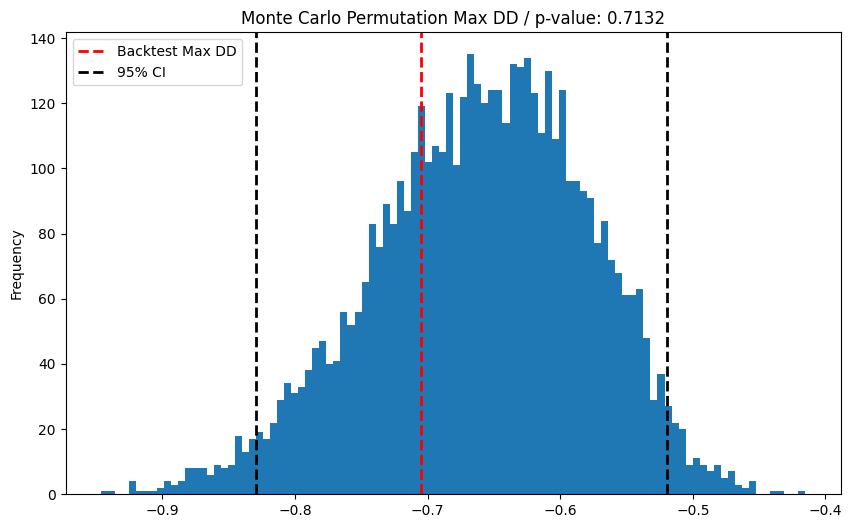

In [17]:
main.mcpyt_analysis(mcpyt, result.returns, ci=95)

<div class="alert alert-block alert-info"><b>Brief Statistical Analysis</b>

Statistically speaking this is a sound strategy! It has proven itself against 0 returns, and has passed Monte Carlo Permutation test, proving that it has an edge, since it's Max DD was lower that 95% CI.

## Out of Sample Validation

In [ ]:
lookbacks

In [ ]:
main.timer.start()
backtest = bt.Backtest(TrendStrategy, df_test, df_test[('BTCUSDT', 'Close')], cash=100_000, commission=0.00)
result = backtest.run(320, 1.5)
main.timer.stop()

In [ ]:
result.stats

In [ ]:
main.plot_performance_drawdown(result.returns, result.benchmark)

##### Returns Analysis

In [ ]:
tools.strategy_performance_metrics(pd.concat([result.returns, result.benchmark], axis=1), steps_per_year=(365*24))

In [ ]:
main.monthly_pos_neg_returns(result.returns)

##### Trades Analysis

In [ ]:
tools.metrics_trades(result.trades)

In [24]:
tools.plot_trades_signals(df_train['BTCUSDT'][['Close', 'BOLL_UP_40_2.5']], result.trades)

KeyError: "['BOLL_UP_40_2.5'] not in index"

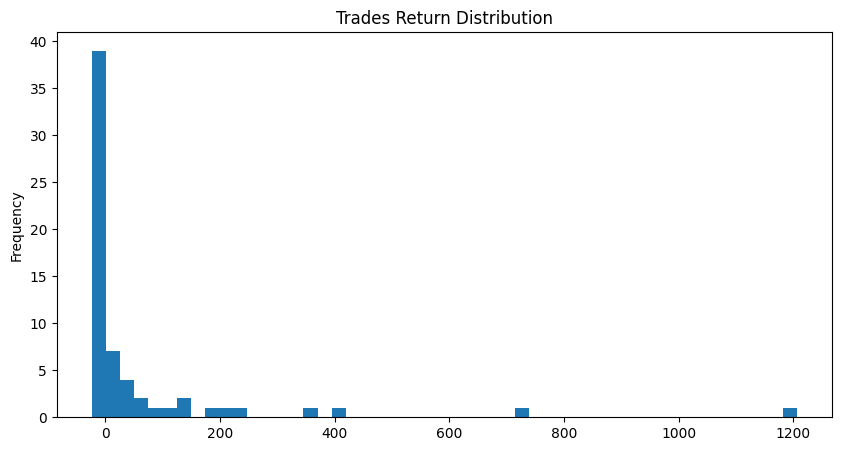

In [23]:
clipped_returns = main.cap_series(result.trades['change_pct'], percentile=0.005)
ax2 = clipped_returns.plot.hist(bins=50, title="Trades Return Distribution", figsize=(10, 5))

In [ ]:
exit_types_df = ((result.trades.groupby(['why_exit']).size()/len(result.trades))*100).sort_values()

ax3 = exit_types_df.plot.barh(title='Exits Types (%)', figsize=(10,5))

<Axes: title={'center': 'Symbols traded (%)'}, ylabel='symbol'>

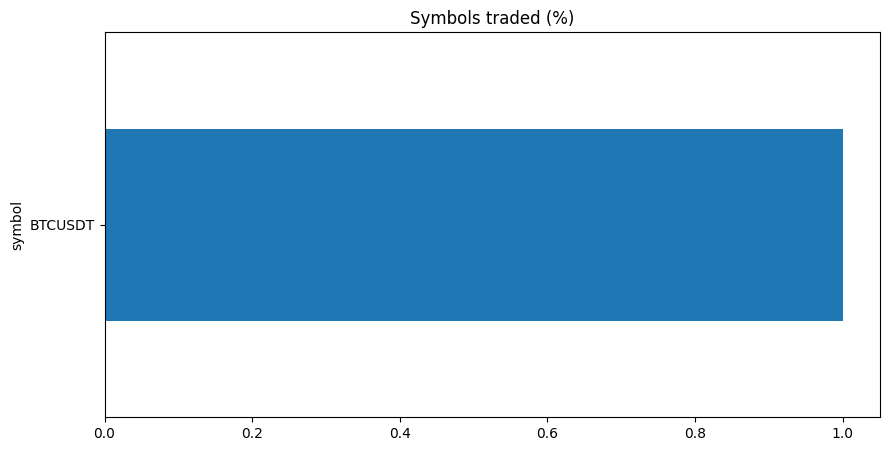

In [21]:
symbols_traded_df = (result.trades.groupby(['symbol']).size()/len(result.trades))

symbols_traded_df.plot.barh(title='Symbols traded (%)', figsize=(10,5))

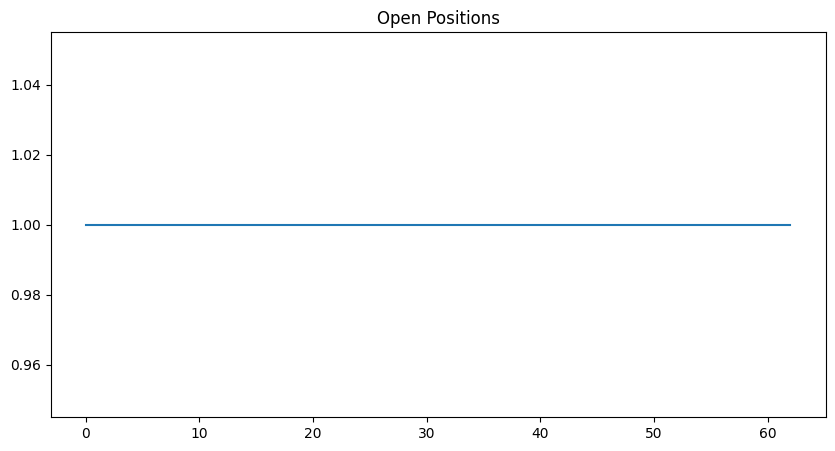

In [20]:
ax4 = result.trades['current_open_positions'].plot(title='Open Positions', figsize=(10, 5))

Avg. Bars Held: 41


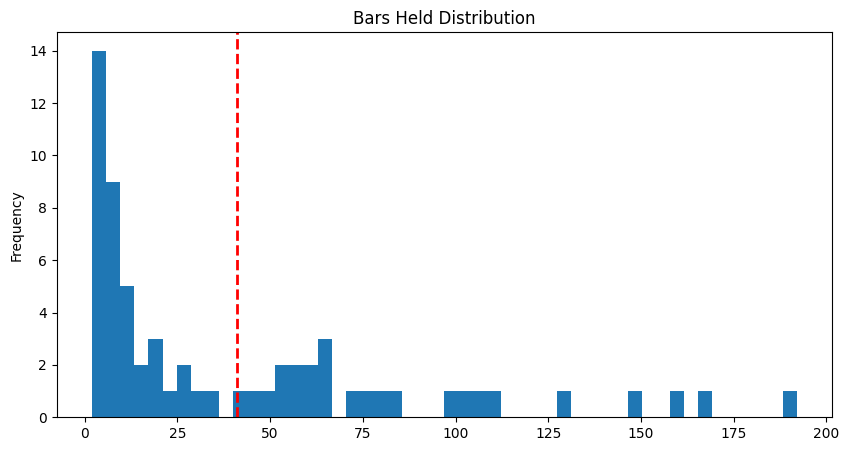

In [19]:
ax1 = result.trades['bars_held'].plot.hist(bins=50, title="Bars Held Distribution", figsize=(10, 5))
ax1.axvline(result.trades['bars_held'].mean(), color='red', linestyle='dashed', linewidth=2)
print("Avg. Bars Held:", int(result.trades['bars_held'].mean()))

In [18]:
# Bar Duration VS Percent Profit
import plotly.express as px

# Fazer scatter plot
ax5 = px.scatter(result.trades, 
                 x='bars_held', 
                 y='change_pct', 
                 width=900, 
                 height=500, 
                 trendline="ols", 
                 trendline_color_override="black", 
                 title='Bar Duration VS Percent Profit',
                 template='seaborn'
                 )

ax5.show()